### Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

###### pandas → Read and manipulate data
###### numpy → Numerical operations
###### matplotlib → Plot graphs
###### TF-IDF → Convert text into numbers
###### KMeans → Clustering algorithm
###### PCA → Reduce dimensions for visualization
###### silhouette_score → Evaluate clustering quality

### Load Dataset

In [5]:
df=pd.read_csv(r"C:\Users\mohammed hamza\Downloads\india-tourism-food-dataset.csv")
df

,City,Tourist Spot 1,Tourist Spot 2,Tourist Spot 3,Breakfast Spot 1,Breakfast Spot 2,Breakfast Spot 3,Dinner Spot 1,Dinner Spot 2,Dinner Spot 3
0,Mumbai,Gateway of India,Marine Drive,Elephanta Caves,"Ram Ashraya, Matunga","Cafe Madras, Matunga","Kyani & Co., Marine Lines","Aaswad, Dadar","Sarvi, Byculla","Candies, Bandra"
1,Delhi,Red Fort,India Gate,Qutub Minar,"Saravana Bhavan, CP","Sita Ram Diwan Chand, Paharganj",Andhra Bhavan Canteen,"Karim's, Jama Masjid","Rajinder Da Dhaba, Safdarjung","Saravana Bhavan, CP"
2,Bangalore,Lalbagh Botanical Garden,Bangalore Palace,Cubbon Park,Vidyarthi Bhavan,CTR (Sri Sagar),Airlines Hotel,"MTR, Lalbagh","Nagarjuna, Residency Road",Rameshwaram Cafe
3,Hyderabad,Charminar,Golconda Fort,Hussain Sagar Lake,"Chutneys, Banjara Hills",Govind Dosas,Ram ki Bandi,Shah Ghouse Cafe,Hotel Shadab,"Bawarchi, RTC X Roads"
4,Chennai,Marina Beach,Kapaleeshwarar Temple,Fort St. George,Murugan Idli Shop,Rayar's Mess,Ratna Cafe,Junior Kuppanna,Mathsya,Sangeetha Veg Restaurant
...,...,...,...,...,...,...,...,...,...,...
63,Ratnagiri,Ganpatipule Temple,Thibaw Palace,Ratnadurg Fort,Hotel Annapurna,Kokani Katta,Sawant Snacks,Atharva Restaurant,Konkan Villa,Hotel Sea Rock
64,Sindhudurg,Sindhudurg Fort,Tarkarli Beach,Malvan Marine Sanctuary,Chaitanya Restaurant,Gajanan Snacks,Malvani Mess,Atithi Bamboo Restaurant,Sawant Malvani,Malvan Kinara
65,Satara,Kaas Plateau,Ajinkyatara Fort,Thoseghar Waterfalls,Sai Bhojanalay,Annapurna Bhavan,Manohar’s Misal,Hotel Shreeman,Maratha Samrat,Lake View Restaurant
66,Ahilyanagar,Shirdi Sai Baba Temple,Ahmednagar Fort,Wet N Joy Water Park,The Project Cafe,Gopi Dining Hall,Jay Bhavani,Agashiye,Gordhan Thal,Swati Snacks


In [6]:
df.head()

,City,Tourist Spot 1,Tourist Spot 2,Tourist Spot 3,Breakfast Spot 1,Breakfast Spot 2,Breakfast Spot 3,Dinner Spot 1,Dinner Spot 2,Dinner Spot 3
0,Mumbai,Gateway of India,Marine Drive,Elephanta Caves,"Ram Ashraya, Matunga","Cafe Madras, Matunga","Kyani & Co., Marine Lines","Aaswad, Dadar","Sarvi, Byculla","Candies, Bandra"
1,Delhi,Red Fort,India Gate,Qutub Minar,"Saravana Bhavan, CP","Sita Ram Diwan Chand, Paharganj",Andhra Bhavan Canteen,"Karim's, Jama Masjid","Rajinder Da Dhaba, Safdarjung","Saravana Bhavan, CP"
2,Bangalore,Lalbagh Botanical Garden,Bangalore Palace,Cubbon Park,Vidyarthi Bhavan,CTR (Sri Sagar),Airlines Hotel,"MTR, Lalbagh","Nagarjuna, Residency Road",Rameshwaram Cafe
3,Hyderabad,Charminar,Golconda Fort,Hussain Sagar Lake,"Chutneys, Banjara Hills",Govind Dosas,Ram ki Bandi,Shah Ghouse Cafe,Hotel Shadab,"Bawarchi, RTC X Roads"
4,Chennai,Marina Beach,Kapaleeshwarar Temple,Fort St. George,Murugan Idli Shop,Rayar's Mess,Ratna Cafe,Junior Kuppanna,Mathsya,Sangeetha Veg Restaurant


In [7]:
df.tail()

,City,Tourist Spot 1,Tourist Spot 2,Tourist Spot 3,Breakfast Spot 1,Breakfast Spot 2,Breakfast Spot 3,Dinner Spot 1,Dinner Spot 2,Dinner Spot 3
63,Ratnagiri,Ganpatipule Temple,Thibaw Palace,Ratnadurg Fort,Hotel Annapurna,Kokani Katta,Sawant Snacks,Atharva Restaurant,Konkan Villa,Hotel Sea Rock
64,Sindhudurg,Sindhudurg Fort,Tarkarli Beach,Malvan Marine Sanctuary,Chaitanya Restaurant,Gajanan Snacks,Malvani Mess,Atithi Bamboo Restaurant,Sawant Malvani,Malvan Kinara
65,Satara,Kaas Plateau,Ajinkyatara Fort,Thoseghar Waterfalls,Sai Bhojanalay,Annapurna Bhavan,Manohar’s Misal,Hotel Shreeman,Maratha Samrat,Lake View Restaurant
66,Ahilyanagar,Shirdi Sai Baba Temple,Ahmednagar Fort,Wet N Joy Water Park,The Project Cafe,Gopi Dining Hall,Jay Bhavani,Agashiye,Gordhan Thal,Swati Snacks
67,Sangli,Ganpati Temple,Sangli Fort,Chandoli National Park,Krishna Bhojanalay,Sangli Sweets,Shree Datta Snacks,Hotel Ambika,Maratha Darbar,Sangli Spice


In [10]:
df.shape

(68, 10)

In [11]:
df.columns

Index(['City', 'Tourist Spot 1', 'Tourist Spot 2', 'Tourist Spot 3',
       'Breakfast Spot 1', 'Breakfast Spot 2', 'Breakfast Spot 3',
       'Dinner Spot 1', 'Dinner Spot 2', 'Dinner Spot 3'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   City              68 non-null     object
 1   Tourist Spot 1    68 non-null     object
 2   Tourist Spot 2    68 non-null     object
 3   Tourist Spot 3    68 non-null     object
 4   Breakfast Spot 1  68 non-null     object
 5   Breakfast Spot 2  68 non-null     object
 6   Breakfast Spot 3  68 non-null     object
 7   Dinner Spot 1     68 non-null     object
 8   Dinner Spot 2     68 non-null     object
 9   Dinner Spot 3     68 non-null     object
dtypes: object(10)
memory usage: 5.4+ KB


### Statistical Summary 

In [13]:
df.describe(include="all")

,City,Tourist Spot 1,Tourist Spot 2,Tourist Spot 3,Breakfast Spot 1,Breakfast Spot 2,Breakfast Spot 3,Dinner Spot 1,Dinner Spot 2,Dinner Spot 3
count,68,68,68,68,68,68,68,68,68,68
unique,68,67,67,68,66,61,60,65,65,67
top,Mumbai,Rock Garden,ISKCON Temple,Elephanta Caves,The Project Cafe,Bikanervala,Cafe Coffee Day,Agashiye,Barbeque Nation,Swati Snacks
freq,1,2,2,1,2,5,5,2,3,2


In [14]:
### Missing Values
df.isnull().sum()

City                0
Tourist Spot 1      0
Tourist Spot 2      0
Tourist Spot 3      0
Breakfast Spot 1    0
Breakfast Spot 2    0
Breakfast Spot 3    0
Dinner Spot 1       0
Dinner Spot 2       0
Dinner Spot 3       0
dtype: int64

In [15]:
### Duplicated Rows
df.duplicated().sum()

np.int64(0)

### Data Claening

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.fillna("", inplace=True)

In [19]:
df.isnull().sum()

City                0
Tourist Spot 1      0
Tourist Spot 2      0
Tourist Spot 3      0
Breakfast Spot 1    0
Breakfast Spot 2    0
Breakfast Spot 3    0
Dinner Spot 1       0
Dinner Spot 2       0
Dinner Spot 3       0
dtype: int64

### Feature Engineering 

In [20]:
df["Combined_Features"] = (
    df["Tourist Spot 1"] + " " +
    df["Tourist Spot 2"] + " " +
    df["Tourist Spot 3"] + " " +
    df["Breakfast Spot 1"] + " " +
    df["Breakfast Spot 2"] + " " +
    df["Breakfast Spot 3"] + " " +
    df["Dinner Spot 1"] + " " +
    df["Dinner Spot 2"] + " " +
    df["Dinner Spot 3"]
)

In [21]:
df[["City", "Combined_Features"]].head()

,City,Combined_Features
0,Mumbai,Gateway of India Marine Drive Elephanta Caves ...
1,Delhi,Red Fort India Gate Qutub Minar Saravana Bhava...
2,Bangalore,Lalbagh Botanical Garden Bangalore Palace Cubb...
3,Hyderabad,Charminar Golconda Fort Hussain Sagar Lake Chu...
4,Chennai,Marina Beach Kapaleeshwarar Temple Fort St. Ge...


### Text Preprocessing 

In [22]:
df["Combined_Features"] = df["Combined_Features"].str.lower()

In [23]:
df["Combined_Features"] = df["Combined_Features"].str.strip()

In [24]:
df["Combined_Features"].head()

0    gateway of india marine drive elephanta caves ...
1    red fort india gate qutub minar saravana bhava...
2    lalbagh botanical garden bangalore palace cubb...
3    charminar golconda fort hussain sagar lake chu...
4    marina beach kapaleeshwarar temple fort st. ge...
Name: Combined_Features, dtype: object

### TF-IDF Vectorization 

In [25]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Combined_Features"])

In [26]:
X.shape

(68, 782)

### Find the Best Number of Clusters (Elbow Method)

In [27]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

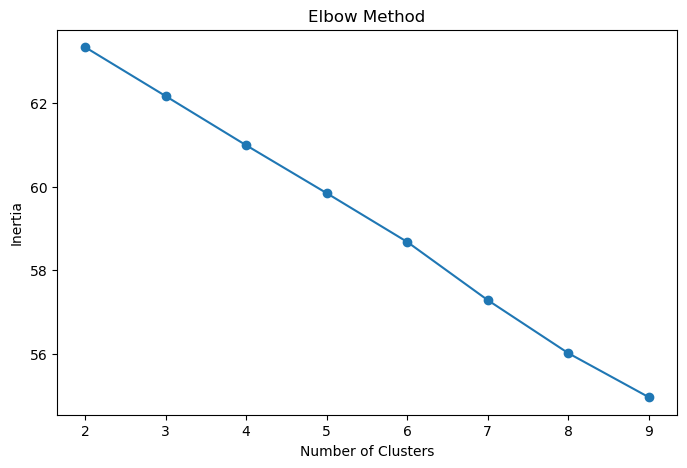

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Train K-Means

In [29]:

kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

In [30]:
df[["City", "Cluster"]]

,City,Cluster
0,Mumbai,3
1,Delhi,1
2,Bangalore,1
3,Hyderabad,3
4,Chennai,1
...,...,...
63,Ratnagiri,1
64,Sindhudurg,1
65,Satara,1
66,Ahilyanagar,3


### Evaluate the Model

In [31]:
score = silhouette_score(X, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.004068448090759596


### Visualize the Clusters

In [32]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())

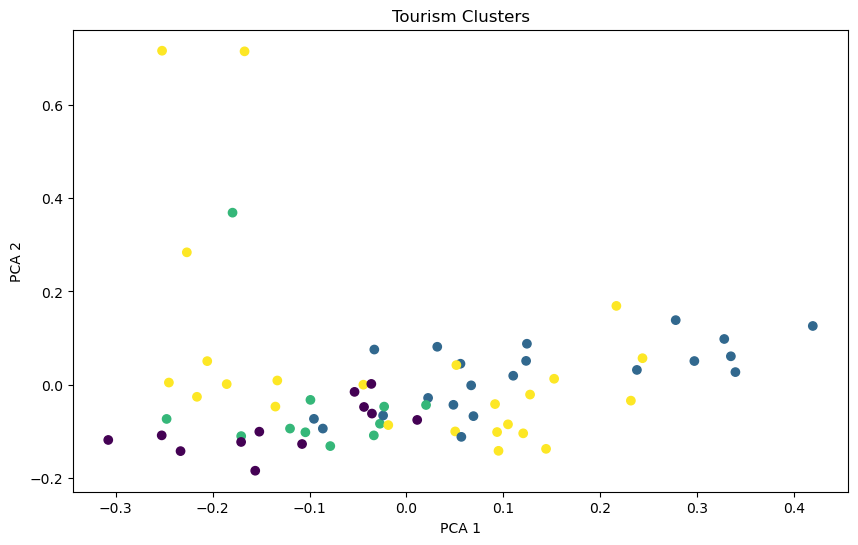

In [33]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Tourism Clusters")

plt.show()

### Analyze the Clusters

In [34]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(df[df["Cluster"] == cluster]["City"].tolist())


Cluster 0
['Kolkata', 'Lucknow', 'Surat', 'Chandigarh', 'Amritsar', 'Ludhiana', 'Dehradun', 'Noida', 'Ghaziabad', 'Jamshedpur', 'Vijayawada', 'Meerut']

Cluster 1
['Delhi', 'Bangalore', 'Chennai', 'Jaipur', 'Nagpur', 'Kochi', 'Madurai', 'Trichy', 'Dhanbad', 'Guwahati', 'Agartala', 'Puducherry', 'Warangal', 'Tirupati', 'Kolhapur', 'Solapur', 'Latur', 'Nanded', 'Ratnagiri', 'Sindhudurg', 'Satara']

Cluster 2
['Pune', 'Indore', 'Bhopal', 'Vadodara', 'Patna', 'Ranchi', 'Jodhpur', 'Thiruvananthapuram', 'Gwalior', 'Bareilly', 'Moradabad']

Cluster 3
['Mumbai', 'Hyderabad', 'Ahmedabad', 'Visakhapatnam', 'Nashik', 'Bhubaneswar', 'Raipur', 'Udaipur', 'Gurgaon', 'Faridabad', 'Coimbatore', 'Shillong', 'Imphal', 'Aizawl', 'Gangtok', 'Itanagar', 'Panaji', 'Mysore', 'Hubli', 'Amravati', 'Chhatrapati Sambhajinagar', 'Raigad', 'Ahilyanagar', 'Sangli']


In [38]:
df.to_csv("tourism_clustered_data.csv", index=False)


### Conclusion :
##### 1)The dataset was cleaned and preprocessed.
##### 2)Tourist attractions and food locations were combined into a         single text feature.
##### 3)TF-IDF converted text into numerical vectors.
##### 4)The Elbow Method was used to determine the optimal number of        clusters.
##### 5)K-Means successfully grouped similar tourist destinations.
##### 6)PCA was used to visualize the clusters.
##### 7)The Silhouette Score was used to evaluate clustering quality.



### Future Scope :
##### 1)Add hotel recommendations.
##### 2)Include user ratings and reviews.
##### 3)Use real-time travel data.
##### 4)Develop a recommendation system based on user preferences.
##### 5)Deploy the model as a web application.
